# Bargain-Bin — a quantitative teardown 🔬
### HML with a Lo t-stat · value-vs-growth Sharpe · the three regimes · the lost-decade drawdown

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A dependable premium?: Not supported](https://img.shields.io/badge/A_dependable_premium%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test value on tradable ETF pairs and locate the premium's regimes.

> ⚠️ **Not investment advice.** IVE/IVW, VTV/VUG, RPV/RPG monthly total return (Yahoo), 2000–2026. Sources in [`docs/references.md`](../docs/references.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (bargain_bin/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from bargain_bin import data, strategy as st
ret = data.fetch_pairs()                       # cache-first; built by examples/verify.py --fetch
hml = st.hml(ret, "IVE", "IVW")                # S&P 500 value minus growth


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | **Weak** | HML −1.1%/yr since 2000; value Sharpe < growth |
| Tradability | **Mirage** | 2007–2020 lost decade, −5%/yr, Sharpe −0.7 |
| Dependable premium? | **Not supported** | strong→negative→flat across regimes |

> 💡 *In plain words:* a real factor trapped in the wrong regime for a generation.

## 1 · The claim, steelmanned

- **H₁:** HML > 0 with |t| > 2 over the full sample.
- **H₂:** value's Sharpe exceeds growth's.
- **H₃:** the premium is stable, not a regime bet.

## 2 · So what? — what rides on each

If H₁/H₂ hold, a value tilt is a durable edge. If H₃ fails, value is a timing call on regimes — a very different thing to sell an investor.

## 3 · How we'd know — the protocol

HML spread per pair → Lo (2002) t-stat → each leg's Sharpe → regime split (pre-2007 / 2007–2020 / 2021-on) → the lost-decade drawdown.

## 4 · The teardown

### 4.1 The spread, with a t-stat

In [2]:
rows={}
for k,(a,b) in {'IVE−IVW':('IVE','IVW'),'VTV−VUG':('VTV','VUG'),'RPV−RPG':('RPV','RPG')}.items():
    if a in ret and b in ret:
        s=st.hml_stats(st.hml(ret,a,b)); rows[k]={'HML %/yr':s['mean_ann']*100,'Sharpe':s['sharpe'],'Lo t':s['tstat'],'n':s['n']}
display(pd.DataFrame(rows).T.round(3))

,HML %/yr,Sharpe,Lo t,n
IVE−IVW,-1.140,-0.119,-0.606,313.0
VTV−VUG,-2.567,-0.257,-1.214,269.0
RPV−RPG,-1.601,-0.109,-0.489,243.0


> 💡 *In plain words:* negative or insignificant on every pair. **H₁ rejected** over the modern sample.

### 4.2 Value trails growth on Sharpe

In [3]:
for a,b in [('IVE','IVW'),('VTV','VUG'),('RPV','RPG')]:
    if a in ret and b in ret:
        print(f'{a} (value) Sharpe {st.leg_summary(ret,a)["sharpe"]:.2f}  vs  {b} (growth) Sharpe {st.leg_summary(ret,b)["sharpe"]:.2f}')

IVE (value) Sharpe 0.54  vs  IVW (growth) Sharpe 0.59
VTV (value) Sharpe 0.70  vs  VUG (growth) Sharpe 0.77
RPV (value) Sharpe 0.51  vs  RPG (growth) Sharpe 0.70


> 💡 *In plain words:* the 'premium' delivered a lower Sharpe than growth. **H₂ rejected.**

### 4.3 The three regimes

In [4]:
pairs={'IVE−IVW':('IVE','IVW'),'VTV−VUG':('VTV','VUG'),'RPV−RPG':('RPV','RPG')}
reg=pd.concat({k: st.regime_split(st.hml(ret,a,b))['mean_ann'] for k,(a,b) in pairs.items() if a in ret and b in ret}, axis=1).T
display((reg*100).round(2))

,pre-2007,2007-2020 (lost decade),2021-on
IVE−IVW,8.08,-4.94,-2.50
VTV−VUG,7.16,-5.18,-1.07
RPV−RPG,13.03,-3.67,1.68


> 💡 *In plain words:* strongly positive pre-2007, deeply negative 2007–2020, flat since. **H₃ rejected** — value is regime-switching, and the lost decade (Israel et al. 2021) dominates.

### 4.4 The lost-decade drawdown

2007-2020 value-vs-growth: cumulative -51.8%, max drawdown -55.2%


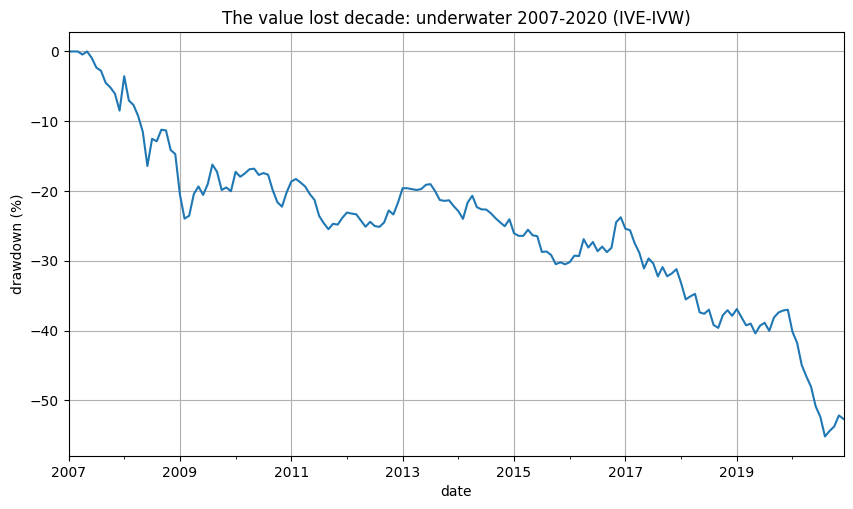

In [5]:
ld = hml.loc['2007':'2020']; eq=(1+ld).cumprod(); dd=(eq/eq.cummax()-1)
print(f'2007-2020 value-vs-growth: cumulative {eq.iloc[-1]-1:+.1%}, max drawdown {dd.min():.1%}')
ax=(dd*100).plot(title='The value lost decade: underwater 2007-2020 (IVE-IVW)'); ax.set_ylabel('drawdown (%)'); plt.show()

## 5 · The verdict

H₁, H₂, H₃ rejected over the modern sample → Signal `WEAK` (real but regime-bound), Tradability `MIRAGE`, dependable-premium `NOT SUPPORTED`.

## 6 · Could you trade it?

Cheaply, yes — but you'd buy a generation of underperformance and a thirteen-year drawdown. Value as a *timing* call (when does the regime turn?) is a different, harder game than value as a *premium*.

## 7 · Going further

Forks: (a) Ken French's HML back to 1926 to see the long-run positive premium and the recent fade together; (b) value *within* sectors (much of value/growth is a sector bet on tech); (c) combine value with momentum (the classic diversifier). Backlog: [`docs/pwb_strategies_inventory.md`](../../../docs/pwb_strategies_inventory.md).